In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install resampy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import tensorflow as tf 
import os
import tensorflow_hub as hub
import resampy
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import numpy as np

print("running TF version",tf.__version__)

running TF version 2.12.0


In [12]:
import numpy as np
import soundfile as sf

import matplotlib.pyplot as plt

import params as yamnet_params
import yamnet as yamnet_model
import tensorflow as tf

In [4]:
# Clone model repo
!git clone https://github.com/tensorflow/models.git
%cd models/research/audioset/yamnet

# Download YAMNet data
!curl -O https://storage.googleapis.com/audioset/yamnet.h5

Cloning into 'models'...
remote: Enumerating objects: 85653, done.
remote: Counting objects: 100% (1252/1252), done.
remote: Compressing objects: 100% (508/508), done.
remote: Total 85653 (delta 789), reused 1168 (delta 738), pack-reused 84401
Receiving objects: 100% (85653/85653), 598.67 MiB | 29.81 MiB/s, done.
Resolving deltas: 100% (61282/61282), done.
/content/models/research/audioset/yamnet
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14.5M  100 14.5M    0     0  47.8M      0 --:--:-- --:--:-- --:--:-- 47.8M


In [16]:
# Clone model repo
!git clone https://github.com/karolpiczak/ESC-50

Cloning into 'ESC-50'...
remote: Enumerating objects: 4193, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 4193 (delta 36), reused 28 (delta 12), pack-reused 4136
Receiving objects: 100% (4193/4193), 878.79 MiB | 27.19 MiB/s, done.
Resolving deltas: 100% (283/283), done.
Updating files: 100% (2011/2011), done.


In [10]:
!ls
!pwd

export.py     params.py		    yamnet.h5	    yamnet_visualization.ipynb
features.py   README.md		    yamnet.py
inference.py  yamnet_class_map.csv  yamnet_test.py
/content/models/research/audioset/yamnet


In [13]:
# The graph is designed for a sampling rate of 16 kHz, but higher rates should work too.
# We also generate scores at a 10 Hz frame rate.
!ls
!pwd

sr = 16000
params = yamnet_params.Params(sample_rate=sr, patch_hop_seconds=0.1)
print("Sample rate =", params.sample_rate)

# Set up the YAMNet model.
class_names = yamnet_model.class_names('yamnet_class_map.csv')
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')

export.py     params.py    yamnet_class_map.csv  yamnet_test.py
features.py   __pycache__  yamnet.h5		 yamnet_visualization.ipynb
inference.py  README.md    yamnet.py
/content/models/research/audioset/yamnet
Sample rate = 16000


In [14]:
## Helper functins
@tf.function
def load_audio_16k_tf(filename):
    file = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
        file,
        desired_channels=1)
    wav = tf.squeeze(wav,axis=-1)
    if len(wav) ==0:
        wav = tf.zeros(4)
    return wav

def load_audio_resample(audio_file: str, target_sr:int=16000):
    """Load wav file and resample to a target frequency
        returns mono resampled signal"""

    x, sample_rate = sf.read(audio_file)
    # check for mono file
    if len(x.shape) > 1:
        x = x.mean(axis=1)
    # check sample rate of audio
    if sample_rate != target_sr:
        x = resampy.resample(x,sample_rate,target_sr)
    return x

In [15]:
## Load ESC-50 DATASET

DATASET_FOLDER = "/Users/wetdog/Documents/07_databases/ESC-50-master/meta/esc50.csv"
AUDIO_FOLDER = "/Users/wetdog/Documents/07_databases/ESC-50-master/audio"
df = pd.read_csv(DATASET_FOLDER)
df["filepath"] = df.apply(lambda x: os.path.join(AUDIO_FOLDER,x["filename"]), axis=1)
df.head()

FileNotFoundError: ignored

In [ ]:
WINDOW_SIZE_SAMPLES = 1024
HOP_SIZE_SAMPLES = 512

filepath = df["filepath"].iloc[0]
x, fs = sf.read(filepath)
signal = tf.Tensor(x,dtype=tf.float32)
print(x.shape)
X = tf.signal.stft(signal,frame_length=WINDOW_SIZE_SAMPLES,
                frame_step=HOP_SIZE_SAMPLES)
X_mag = tf.abs(X)

mel_filterbank = tf.signal.linear_to_mel_weight_matrix(num_mel_bins=64,
                num_spectrogram_bins=513,
                sample_rate=fs,
                lower_edge_hertz=60.0,
                upper_edge_hertz=8000.0,

                name=None,)

print(mel_filterbank.shape)
print(X_mag.shape)

X_mel = tf.matmul(tf.square(X_mag),mel_filterbank)

TypeError: __init__() missing 1 required positional argument: 'value_index'

In [ ]:
np.squeeze(x.shape)

NameError: name 'np' is not defined

In [ ]:
tf.signal.linear_to_mel_weight_matrix?

Signature:
tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=20,
    num_spectrogram_bins=129,
    sample_rate=8000,
    lower_edge_hertz=125.0,
    upper_edge_hertz=3800.0,
    dtype=tf.float32,
    name=None,
)
Docstring:
Returns a matrix to warp linear scale spectrograms to the [mel scale][mel].

Returns a weight matrix that can be used to re-weight a `Tensor` containing
`num_spectrogram_bins` linearly sampled frequency information from
`[0, sample_rate / 2]` into `num_mel_bins` frequency information from
`[lower_edge_hertz, upper_edge_hertz]` on the [mel scale][mel].

This function follows the [Hidden Markov Model Toolkit
(HTK)](http://htk.eng.cam.ac.uk/) convention, defining the mel scale in
terms of a frequency in hertz according to the following formula:

    $$\textrm{mel}(f) = 2595 * \textrm{log}_{10}(1 + \frac{f}{700})$$

In the returned matrix, all the triangles (filterbanks) have a peak value
of 1.0.

For example, the returned matrix `A` can be used to right-multiply 

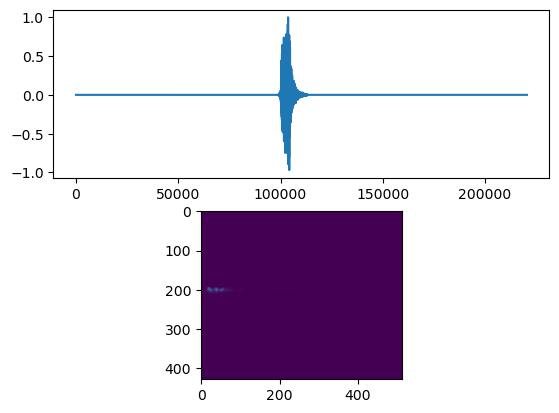

In [ ]:
fig, ax = plt.subplots(nrows=2,ncols=1)

ax[0].plot(x)
ax[1].imshow(X_mag)

In [ ]:
tf.signal.stft?

Signature:
tf.signal.stft(
    signals,
    frame_length,
    frame_step,
    fft_length=None,
    window_fn=<function hann_window at 0x17a50e160>,
    pad_end=False,
    name=None,
)
Docstring:
Computes the [Short-time Fourier Transform][stft] of `signals`.

Implemented with TPU/GPU-compatible ops and supports gradients.

Args:
  signals: A `[..., samples]` `float32`/`float64` `Tensor` of real-valued
    signals.
  frame_length: An integer scalar `Tensor`. The window length in samples.
  frame_step: An integer scalar `Tensor`. The number of samples to step.
  fft_length: An integer scalar `Tensor`. The size of the FFT to apply.
    If not provided, uses the smallest power of 2 enclosing `frame_length`.
  window_fn: A callable that takes a window length and a `dtype` keyword
    argument and returns a `[window_length]` `Tensor` of samples in the
    provided datatype. If set to `None`, no windowing is used.
  pad_end: Whether to pad the end of `signals` with zeros when the provided
   

In [ ]:
def process_audioclio(filepath):
    x, fs = sf.read(filepath)
    tf.signal.fft(frame_length=WINDOW_SIZE_SAMPLES,
                    frame_step=HOP_SIZE_SAMPLES))

In [ ]:
# preprocess dataset


In [ ]:
# define model 
yamnet_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet = hub.load(yamnet_handle)

Metal device set to: Apple M2

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2022-10-21 18:32:07.131172: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-10-21 18:32:07.131438: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
model = tf.keras.Input(tens)

In [ ]:
# test loading function 

x = load_audio_resample(df["filepath"].iloc[4],16000)

In [ ]:
filenames = df["filepath"]
targets = df["target"]
folds = df["fold"]

main_ds = tf.data.Dataset.from_tensor_slices((filenames,targets,folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
main_ds

<TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
def load_wav_for_map(filename, label, fold):
    load_audio_16k_tf(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)

InvalidArgumentError: Length for attr 'output_shapes' of 0 must be at least minimum 1
	; NodeDef: {{node MapDataset}}; Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=metadata:string,default=""> [Op:MapDataset]